CV Assignment-Lecture 2-CNN
Advanced 3-block CNN with BatchNorm, 99.33% accuracy(Improved)

In [1]:

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
tf.random.set_seed(42)
np.random.seed(42)

In [3]:
# Load and preprocess MNIST

num_classes = 10
input_shape = (28, 28, 1)

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

# Manual train and val split with 10% validation
val_frac = 0.1
n_val = int(len(x_train) * val_frac)

x_val, y_val = x_train[:n_val], y_train[:n_val]
x_train2, y_train2 = x_train[n_val:], y_train[n_val:]

print("Train:", x_train2.shape, "Val:", x_val.shape, "Test:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (54000, 28, 28, 1) Val: (6000, 28, 28, 1) Test: (10000, 28, 28, 1)


In [4]:
model = keras.Sequential(
    [
        keras.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        # Block 2
        layers.Conv2D(64, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        # Block 3
        layers.Conv2D(128, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        # Head
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),              # Dropout #1 (keep)
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),              # Dropout #2 (optional, keep as requested)
        layers.Dense(num_classes, activation="softmax"),
    ],
    name="mnist_cnn_3blocks",
)

model.summary()

Model: "mnist_cnn_3blocks"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 110,698 (432.41 KB)

 Non-trainable params: 448 (1.75 KB)

In [5]:

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)
history = model.fit(
    x_train, y_train,
    epochs=20,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.7901 - loss: 0.6450 - val_accuracy: 0.9397 - val_loss: 0.1926
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9617 - loss: 0.1267 - val_accuracy: 0.9513 - val_loss: 0.1662
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9724 - loss: 0.0914 - val_accuracy: 0.9768 - val_loss: 0.0670
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9776 - loss: 0.0737 - val_accuracy: 0.9640 - val_loss: 0.1034
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9817 - loss: 0.0610 - val_accuracy: 0.9890 - val_loss: 0.0314
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9844 - loss: 0.0524 - val_accuracy: 0.9860 - val_loss: 0.0441
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9854 - loss: 0.0459 - val_accuracy: 0.9923 - val_loss: 0.0240
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9878 - loss: 0.0390 -

In [6]:
# Evaluate and Plot

val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print("\nFinal metrics:")
print(f"Validation accuracy: {val_acc:.4f}")
print(f"Test accuracy:       {test_acc:.4f}")





Final metrics:
Validation accuracy: 0.9978
Test accuracy:       0.9933


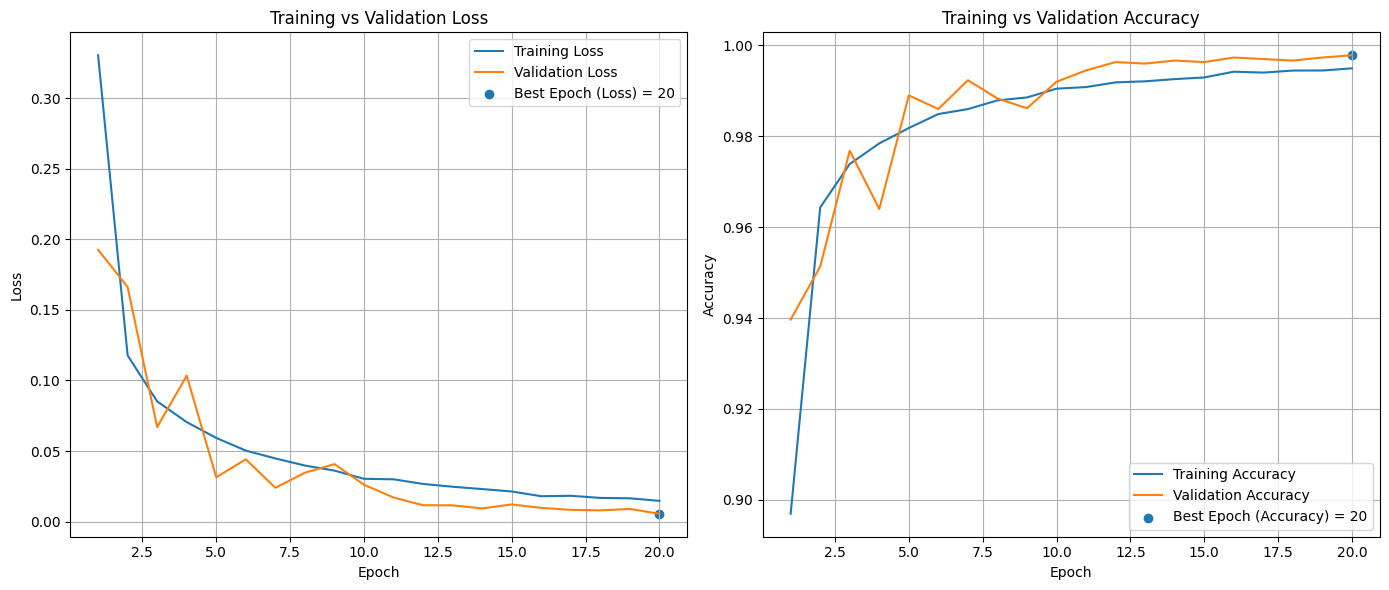

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Extract history data
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

epochs = range(1, len(train_loss) + 1)

# Best epochs
best_epoch_accuracy = np.argmax(val_accuracy) + 1
best_epoch_loss = np.argmin(val_loss) + 1

plt.figure(figsize=(14, 6))

# Plot 1: Loss

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

plt.scatter(best_epoch_loss, val_loss[best_epoch_loss - 1],
            label=f'Best Epoch (Loss) = {best_epoch_loss}')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracy, label='Training Accuracy')
plt.plot(epochs, val_accuracy, label='Validation Accuracy')

plt.scatter(best_epoch_accuracy, val_accuracy[best_epoch_accuracy - 1],
            label=f'Best Epoch (Accuracy) = {best_epoch_accuracy}')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()